In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import pandas as pd
import os
import re
import warnings

from matplotlib.ticker import FuncFormatter
from labellines import labelLines, labelLine

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 16,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='06-few-shot-from-scratch-non-dp'

# width of the thesis in points
WIDTH = 469.75499
OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

# Beamer 16:9
#WIDTH=455.24408
#OUTPUT_DIR='/home/arehn/presentations/meeting-20241201/images/'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'pdf'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'wrn-16-4': 'WRN-16-4',
    'koskela-net': 'KoskelaNet',
}

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def prepare_data(data):
    records = []
    for experiment_id, experiment_details in data.items():
        # Extracting values from the JSON structure
        seed = subset_size = experiment_details['configuration']['seed']
        shots = experiment_details['configuration']['shots']
        batch_size = experiment_details['best_params']['batch_size']
        learning_rate = experiment_details['best_params']['learning_rate']
        epochs = experiment_details['best_params']['epochs']
        
        # Handling the full batch size case
        if batch_size == -1:
            full_batch_size = 5000 if subset_size == 0.1 else 50000
            batch_size = full_batch_size

        record = {
            'experiment_id': experiment_id,
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'shots': shots,
            'batch_size': batch_size,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'epochs': epochs,
            'seed': seed,
        }
        records.append(record)

    return pd.DataFrame(records)

# Replicate the plot from the paper

In [6]:
# Data from the paper: CIFAR-10 from scratch
paper_epsilon = [1, 2, 4, 8]
paper_accuracy = [56.8, 65.9, 73.5, 81.4]

In [7]:
def plot_paper_data(epsilon, accuracy):
    plt.plot(epsilon, accuracy, marker='o', linestyle='-', color='b')

    plt.title('CIFAR-10 Accuracy vs. Epsilon (DP-SGD)')
    plt.xlabel('Epsilon')
    plt.ylabel('Accuracy (\%)')
    plt.grid(True)

    plt.show()

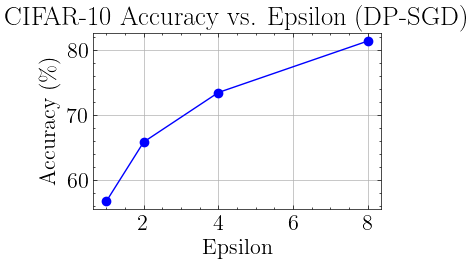

In [8]:
plot_paper_data(paper_epsilon, paper_accuracy)

# A function for plotting our data

In [9]:
def plot_accuracy_trends(processed_data, model_name=None, output_dir=None):
    # Sort for consistent colors across plot variations
    processed_data.sort_values(['model_name', 'shots'], inplace=True)
    
    # Filter data for the specified model if model_name is provided
    if model_name:
        processed_data = processed_data[processed_data['model_name'] == model_name]
    
    # Create a figure for plotting
    fig, ax = get_figure((1,1))
        
    # Group by model_name to plot each model's accuracy trend
    model_groups = processed_data.groupby('model_name')
    
    for model_name, group in model_groups:
        # Plot shots vs. accuracy
        ax.plot(group['shots'], group['accuracy'], label=MODEL_NAME_MAP.get(model_name, model_name), marker='o')
        
    # Set title and labels
    ax.set_title('Model accuracy by shots')
    ax.set_xlabel('Shots')
    ax.set_ylabel('Accuracy (\%)')
    
    # Plot x-axis on log scale
    ax.set_xscale('log')
    
    # Set the number of shots as x-axis ticks
    shots_values = sorted(processed_data['shots'].unique())
    ax.set_xticks(shots_values)
    
    # Rotate x-axis labels for better readability
    ax.set_xticklabels(shots_values, rotation=45, size=15)
    
    # Set y-axis grid lines at 0.1, 0.2, 0.3, ...
    ax.set_yticks([i / 10.0 for i in range(0, 11)])
    ax.grid(axis='y', which='major', linestyle='--')

    # Add grid lines for the x-axis
    ax.grid(axis='x', which='major', linestyle='--')
    
    # Set y-axis limit
    ax.set_ylim([0, 1])
    
    # Format y-axis labels to show as percentages
    formatter = FuncFormatter(lambda y, _: '{:.0%}'.format(y))
    ax.yaxis.set_major_formatter(formatter)
    
    # Add legend
    ax.legend()

    # Save the plot if an output directory is provided
    if output_dir:
        filename_suffix = model_name if model_name else 'all_models'
        filename = f'accuracy_by_shots_{filename_suffix}.pdf'
        plt.savefig(os.path.join(output_dir, filename))
    
    # Show the plot
    plt.show()

# Plot for shots vs accuracy from our experiment

In [10]:
def plot(model_name=None):
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    
    # Load and prepare your data
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    
    # Plot the trends
    plot_accuracy_trends(processed_data, model_name=model_name, output_dir=OUTPUT_DIR)

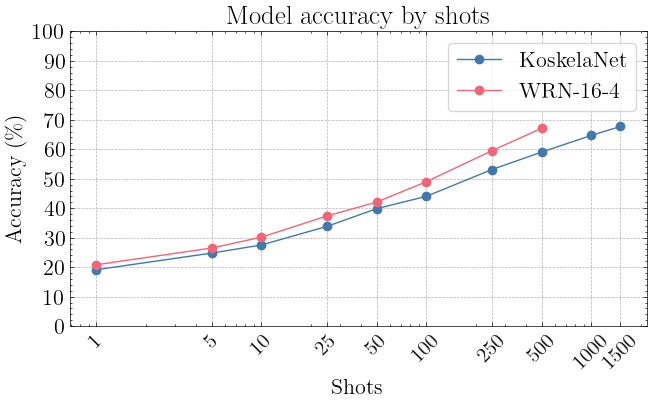

In [11]:
plot()
#plot(model_name='koskela-net')
#plot(model_name='wrn-16-4')

# Final plot that combines our experiment data with the (De et al., 2022) data

In [28]:
def plot_accuracy_trends(processed_data, paper_data=None, output_dir=None, model_name=None):
    # Sort for consistent colors across plot variations
    processed_data.sort_values(['model_name', 'shots'], inplace=True)
    
    # Filter data for the specified model if model_name is provided
    if model_name:
        processed_data = processed_data[processed_data['model_name'] == model_name]
    
    # Create a figure for plotting
    fig, ax = get_figure((1,1))
        
    # Group by model_name to plot each model's accuracy trend
    model_groups = processed_data.groupby('model_name')
        
    for model, group in model_groups:
        # Plot shots vs. accuracy
        ax.plot(group['shots'], group['accuracy'], label=MODEL_NAME_MAP.get(model, model), marker='o')
        
    # Set title and labels
    ax.set_title('Model accuracy by shots')
    ax.set_xlabel('Shots')
    ax.set_ylabel('Accuracy (\%)')
    
    # Plot x-axis on log scale
    ax.set_xscale('log')
    
    # Set the number of shots as x-axis ticks
    shots_values = sorted(processed_data['shots'].unique())
    ax.set_xticks(shots_values)
    
    # Rotate x-axis labels for better readability
    ax.set_xticklabels(shots_values, rotation=45, fontsize=15)
    
    # Set y-axis grid lines at 0.1, 0.2, 0.3, ...
    ax.set_yticks([i / 10.0 for i in range(0, 11)])
    ax.grid(axis='y', which='major', linestyle='--')

    # Adding grid lines for the x-axis
    ax.grid(axis='x', which='major', linestyle='--')
    
    # Set y-axis limit
    ax.set_ylim([0, 1])
    
    # Format y-axis labels to show as percentages
    formatter = FuncFormatter(lambda y, _: '{:.0%}'.format(y))
    ax.yaxis.set_major_formatter(formatter)
    
    # Add legend for model lines
    ax.legend()

    if paper_data:
        paper_epsilon = paper_data['epsilon']
        paper_accuracy = paper_data['accuracy']

        # Convert accuracy to fraction for plotting
        paper_accuracy_fraction = [acc / 100.0 for acc in paper_accuracy]

        # Define the x positions where the labels will be placed
        x_positions = [5, 25, 100, 500]
        
        xmin, xmax = ax.get_xlim()

        # Plot horizontal lines for paper accuracies and add labels using labelLines
        for eps, acc, x_pos in zip(paper_epsilon, paper_accuracy_fraction, x_positions):
            line, = ax.plot([xmin, xmax], [acc, acc], color='black', linestyle='--', linewidth=1)

            # Use labelLine to label this line at the position x_pos
            labelLine(line, x=x_pos, label=f'$\epsilon={eps}$', backgroundcolor='white', fontsize=12)

    # Save the plot if an output directory is provided
    if output_dir:
        filename_suffix = model_name if model_name else 'all_models'
        filename = f'accuracy_by_shots_{filename_suffix}.png'
        plt.savefig(os.path.join(output_dir, filename))
    
    # Show the plot
    plt.show()


In [29]:
def plot(paper_data, model_name=None):
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    
    # Load and prepare your data
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    
    # Plot the trends
    plot_accuracy_trends(processed_data, paper_data=paper_data, model_name=model_name, output_dir=OUTPUT_DIR)

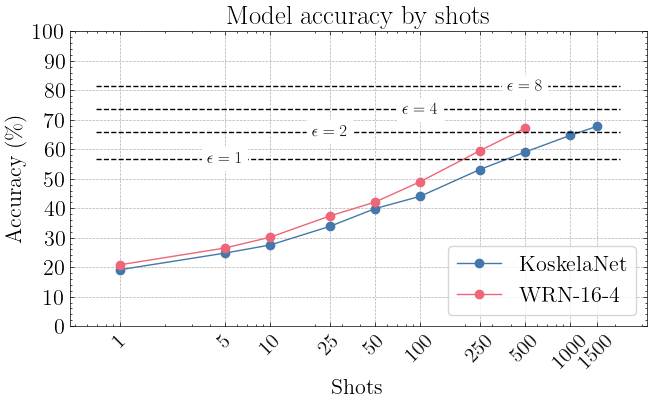

In [30]:
paper_data = {
    'accuracy': paper_accuracy,
    'epsilon': paper_epsilon,
}

plot(paper_data=paper_data)